# Titanic Dataset Survivor Detector Using XGboost

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier



In [34]:
data_path = "../../../datasets/titanic/train.csv"
raw_df = pd.read_csv(data_path)

df = raw_df.copy().drop(columns = ['Cabin', 'Ticket', 'Name'])

In [35]:
df = pd.get_dummies(df, columns = ['Embarked'], dtype = int)

df['Sex_Encoded'] = df['Sex'].apply(lambda x: 1 if x == 'male' else 0)
df['Family'] = df['SibSp'] + df['Parch'] + 1
df['Fare'] = df['Fare'].apply(np.log1p).fillna(df.groupby('Pclass')['Fare'].transform('mean'))
df['Age'] = df['Age'].fillna(df['Age'].median())
df['IsAlone'] = (df['Family'] ==  1).astype(int)



In [36]:
data = df.drop(columns = ['PassengerId', 'SibSp', 'Parch', 'Sex'])
X = data.drop(columns = ['Survived']).to_numpy()
y = data['Survived'].to_numpy()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
xg_baseline = XGBClassifier()
start = time.time()
xg_baseline.fit(X_train, y_train)

end = time.time()

print(end-start)

pred = xg_baseline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, pred)}")

0.07106351852416992
Accuracy: 0.7932960893854749


In [38]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

xgb_early = XGBClassifier(n_estimators = 1000, early_stopping_rounds = 20)
xgb_early.fit(
    X_train_sub,
    y_train_sub,
    eval_set = [(X_val, y_val)],
    verbose = True
)

print(f"Optimal Stopping Round: {xgb_early.best_iteration}\nAccuracy: {accuracy_score(y_test, xgb_early.predict(X_test))}")

[0]	validation_0-logloss:0.54341
[1]	validation_0-logloss:0.48814
[2]	validation_0-logloss:0.45259
[3]	validation_0-logloss:0.43876
[4]	validation_0-logloss:0.42986
[5]	validation_0-logloss:0.42184
[6]	validation_0-logloss:0.42583
[7]	validation_0-logloss:0.43007
[8]	validation_0-logloss:0.43414
[9]	validation_0-logloss:0.43323
[10]	validation_0-logloss:0.43315
[11]	validation_0-logloss:0.43505
[12]	validation_0-logloss:0.44552
[13]	validation_0-logloss:0.44772
[14]	validation_0-logloss:0.44859
[15]	validation_0-logloss:0.45086
[16]	validation_0-logloss:0.45551
[17]	validation_0-logloss:0.45809
[18]	validation_0-logloss:0.46393
[19]	validation_0-logloss:0.46620
[20]	validation_0-logloss:0.46480
[21]	validation_0-logloss:0.47631
[22]	validation_0-logloss:0.47700
[23]	validation_0-logloss:0.48623
[24]	validation_0-logloss:0.48498
[25]	validation_0-logloss:0.48598
Optimal Stopping Round: 5
Accuracy: 0.8324022346368715


In [39]:
results = []

learning_rate_list = [0.01, 0.1, 0.3]
max_depth_list = [3, 5, 7]

for lr in learning_rate_list:
    for depth in max_depth_list:
        xg = XGBClassifier(n_estimators = 1000, early_stopping_rounds = 20, learning_rate=lr, max_depth=depth)
        xg.fit(
            X_train_sub,
            y_train_sub,
            eval_set = [(X_val, y_val)],
            verbose = False
        )

        preds = xg.predict(X_test)
        acc = accuracy_score(y_test, preds)

        results.append({
            "learning_rate" : lr,
            "max_depth" : depth,
            "accuracy" : acc,
            "best_iteration" : xg.best_iteration
        })




In [40]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="accuracy", ascending=False)

print("Hyperparameter Results:")
print(results_df)

Hyperparameter Results:
   learning_rate  max_depth  accuracy  best_iteration
2           0.01          7  0.832402             193
5           0.10          7  0.826816              25
8           0.30          7  0.821229               7
4           0.10          5  0.821229              27
1           0.01          5  0.815642             302
7           0.30          5  0.810056               8
0           0.01          3  0.798883             290
3           0.10          3  0.798883              30
6           0.30          3  0.798883               8


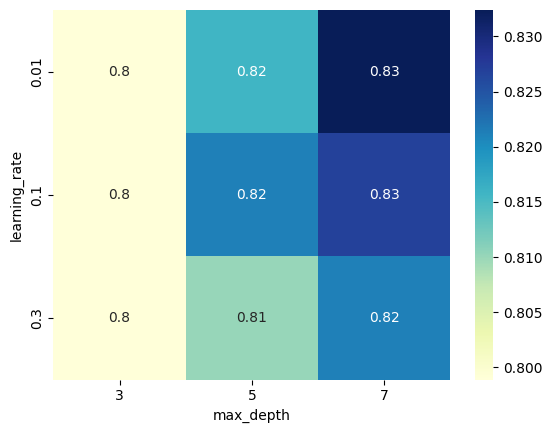

In [41]:
heatmap_data = results_df.pivot_table(index="learning_rate", columns = "max_depth", values = "accuracy")
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu")

plt.show()

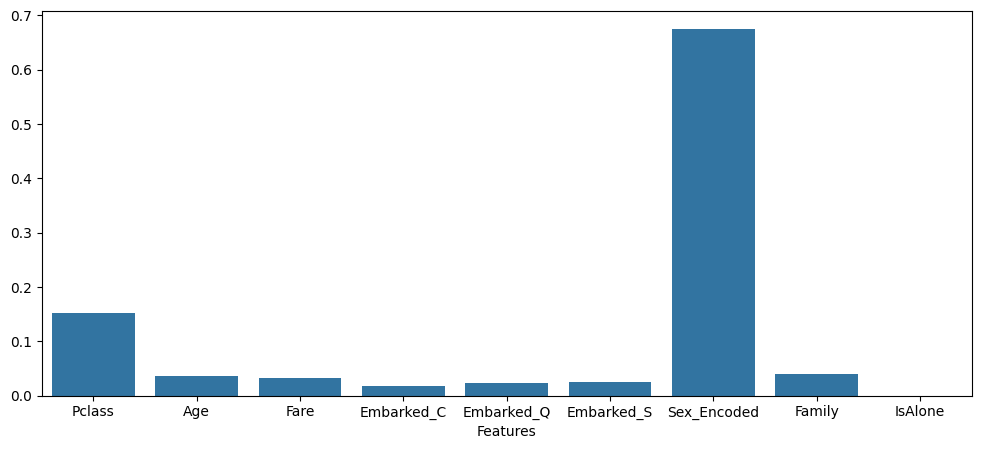

In [43]:
xgb_best = XGBClassifier(n_estimators = 1000, early_stopping_rounds = 193, learning_rate = 0.01, max_depth = 7)
xgb_best.fit(
    X_train_sub,
    y_train_sub,
    eval_set = [(X_val, y_val)],
    verbose = False
)

plt.figure(figsize = (12,5))

sns.barplot(x = df.drop(columns = ['PassengerId', 'SibSp', 'Parch', 'Sex', 'Survived']).columns, y = xgb_best.feature_importances_)
plt.xlabel('Features')
plt.show()